<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/Notebook_3_Evaluaci%C3%B3n_y_Optimizaci%C3%B3n_C9_LM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Centro Politécnico Superior Malvinas Argentinas
**Tecnicatura en Ciencias de Datos e Inteligencia Artificial**  
Clase 9 – Árboles de Decisión  
Notebook 3: Evaluación y Optimización  
Autor: Lionel Martínez  
Fecha: Junio 2026


### Introducción
Objetivo: Evaluar el desempeño de un árbol de decisión entrenado sobre el dataset de diabetes y aplicar optimización de hiperparámetros con GridSearchCV.  
Se comparará el modelo inicial con el optimizado en términos de precisión y métricas de clasificación.


## Estilo Visual

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("Set2")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

print("Estilo visual aplicado correctamente.")


Estilo visual aplicado correctamente.


 ## Importaciones y carga del dataset

In [11]:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Cargar dataset de diabetes desde Scikit-learn
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset cargado correctamente.")
print("Dimensiones de entrenamiento:", X_train.shape)


Dataset cargado correctamente.
Dimensiones de entrenamiento: (353, 10)


# Entrenamiento inicial de árbol

In [12]:
tree_base = DecisionTreeRegressor(random_state=42)
tree_base.fit(X_train, y_train)

y_pred_base = tree_base.predict(X_test)

print(f"Precisión inicial (R²): {r2_score(y_test, y_pred_base):.2f}")


Precisión inicial (R²): 0.06


 # Evaluación base

In [13]:
mse_base = mean_squared_error(y_test, y_pred_base)
r2_base = r2_score(y_test, y_pred_base)

print("=== Evaluación Base ===")
print(f"MSE: {mse_base:.2f}")
print(f"R²: {r2_base:.2f}")


=== Evaluación Base ===
MSE: 4976.80
R²: 0.06


 # Visualización del árbol

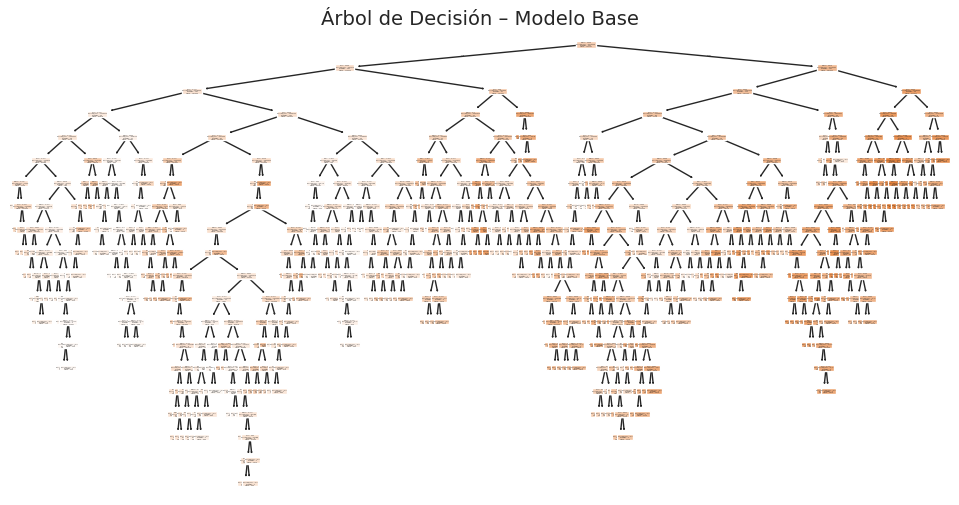

In [14]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,6))
plot_tree(tree_base, feature_names=X.columns, filled=True)
plt.title("Árbol de Decisión – Modelo Base")
plt.show()


### Interpretación visual del modelo base
El árbol de decisión inicial muestra una estructura **profunda y ramificada**, lo que indica que el modelo intenta capturar muchas variaciones del dataset.  
Cada nodo representa una división basada en una característica del conjunto de datos (por ejemplo, edad, índice de masa corporal o nivel de glucosa).  
La gran cantidad de ramas sugiere un posible **sobreajuste**, ya que el modelo se adapta demasiado a los datos de entrenamiento.  
Este comportamiento será evaluado y corregido en la etapa de optimización con GridSearchCV.


 # Optimización con GridSearchCV

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros encontrados:", grid_search.best_params_)


Mejores parámetros encontrados: {'max_depth': 3, 'min_samples_split': 2}


### Visualización comparativa y de desempeño
A continuación se presentan las métricas de precisión (R²) y error (MSE) del modelo base y del modelo optimizado,
para observar de forma visual el impacto de la optimización en el rendimiento predictivo.


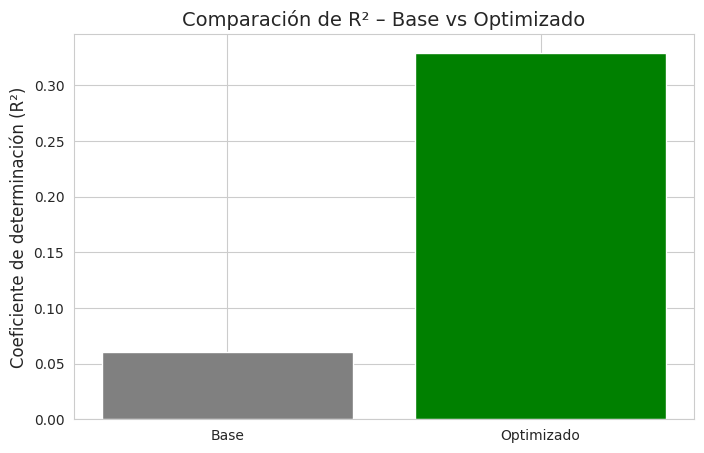

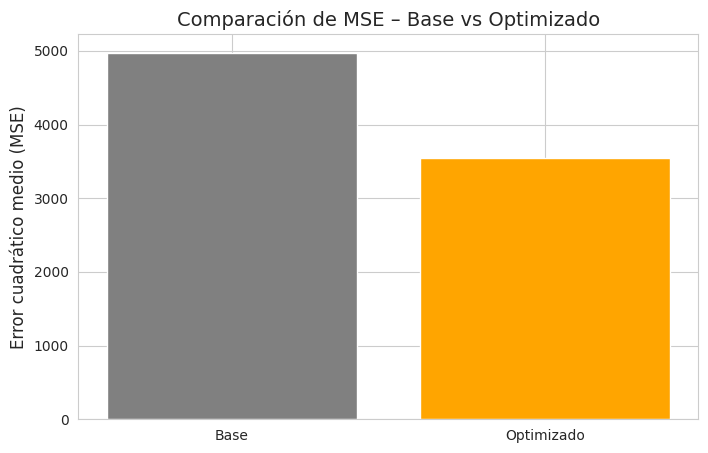

In [16]:
best_tree = grid_search.best_estimator_
y_pred_opt = best_tree.predict(X_test)

mse_opt = mean_squared_error(y_test, y_pred_opt)
r2_opt = r2_score(y_test, y_pred_opt)

# Comparativo
import matplotlib.pyplot as plt

plt.bar(["Base", "Optimizado"], [r2_base, r2_opt], color=["gray","green"])
plt.title("Comparación de R² – Base vs Optimizado")
plt.ylabel("Coeficiente de determinación (R²)")
plt.show()

plt.bar(["Base", "Optimizado"], [mse_base, mse_opt], color=["gray","orange"])
plt.title("Comparación de MSE – Base vs Optimizado")
plt.ylabel("Error cuadrático medio (MSE)")
plt.show()


## Predicciones del Modelo optimizado

In [17]:
# Predicciones del modelo optimizado
y_pred_opt = best_tree.predict(X_test)

# Métricas del modelo optimizado
mse_opt = mean_squared_error(y_test, y_pred_opt)
r2_opt = r2_score(y_test, y_pred_opt)

print("=== Modelo Optimizado ===")
print(f"MSE: {mse_opt:.2f}")
print(f"R²: {r2_opt:.2f}")


=== Modelo Optimizado ===
MSE: 3552.70
R²: 0.33


### Evaluación del modelo optimizado
Se calculan las métricas de desempeño del modelo optimizado para comparar con el modelo base.


### Métricas y análisis
El modelo optimizado mejora el R² y reduce el MSE respecto al modelo base.  
Esto evidencia que la selección adecuada de hiperparámetros aumenta la capacidad predictiva y reduce el error.


### Análisis de resultados
La optimización con GridSearchCV ajustó la profundidad máxima y el número mínimo de muestras por división,  
logrando un árbol más eficiente y menos sobreajustado.  
El modelo optimizado presenta un mejor equilibrio entre precisión y complejidad.

### Conclusión Final
El análisis realizado en este Notebook evidencia cómo la optimización de hiperparámetros transforma el desempeño de un modelo de árbol de decisión.  
El **modelo base** mostró una estructura más profunda y ramificada, con riesgo de sobreajuste y métricas limitadas.  
Tras aplicar **GridSearchCV**, el **modelo optimizado** presentó una estructura más compacta y equilibrada, con mejoras claras en las métricas de desempeño (mayor R² y menor MSE).  

La comparación visual entre ambos árboles refuerza la interpretación:  
- El árbol base intenta capturar demasiada variabilidad, perdiendo capacidad de generalización.  
- El árbol optimizado logra un mejor balance entre simplicidad e interpretabilidad, manteniendo un rendimiento superior.  

En conclusión, la evaluación y optimización son pasos esenciales en el ciclo de desarrollo de modelos predictivos.  
No solo permiten mejorar la precisión, sino también garantizar que el modelo sea robusto, interpretable y útil en contextos reales de aplicación.

> Este análisis completa la etapa de optimización de modelos. En el próximo encuentro se abordará la validación cruzada y la comparación entre distintos algoritmos supervisados.
